# PaddleOCR experiment

Standalone notebook to try PaddleOCR against the real tag photos in `tests/fixtures/`, and experiment freely. Nothing here touches the app -- it's a sandbox.

**Kernel:** select "Python (igi-ocr)" (the project's conda env). PaddleOCR itself is installed by the pip cell below the first time you run this notebook.

See `easyocr_experiment.ipynb` and `tesseract_experiment.ipynb` for the other two engines.

## Setup

In [1]:
!pip install paddlepaddle paddleocr


  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/104.8 MB ? eta -:--:--
    --------------------------------------- 1.8/104.8 MB 9.1 MB/s eta 0:00:12
   - -------------------------------------- 3.4/104.8 MB 8.4 MB/s eta 0:00:13
   -- ------------------------------------- 5.5/104.8 MB 8.8 MB/s eta 0:00:12
   -- ------------------------------------- 7.3/104.8 MB 8.7 MB/s eta 0:00:12
   --- ------------------------------------ 9.7/104.8 MB 9.2 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/104.8 MB 8.9 MB/s eta 0:00:11
   ----- ---------------------------------- 13.4/104.8 MB 9.1 MB/s eta 0:00:11
   ----- ---------------------------------- 15.2/104.8 MB 8.9 MB/s eta 0:00:11
   ------ --------------------------------- 17.0/104.8 MB 8.9 MB/s eta 0:00:10
   ------- -

In [3]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------ --------------------- 4.2/9.3 MB 13.9 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 9.7 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.4 MB 6.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.4 MB 4.5 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.4 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 2.7 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------

In [1]:
import os
os.environ["PYTHONIOENCODING"] = "utf-8"  # avoids a Windows console crash in progress bars

# Works around a NotImplementedError crash in this PaddlePaddle build's oneDNN
# (MKL-DNN) CPU backend ("ConvertPirAttribute2RuntimeAttribute not support
# [pir::ArrayAttribute<pir::DoubleAttribute>]") -- must be set before PaddleOCR
# is imported, since paddlex reads it once at import time.
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "False"

import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

FIXTURES_DIR = Path("tests/fixtures")

# Ground truth read directly off each tag photo, for scoring.
CASES = [
    ("sample_tag.jpeg", "809614206", "CVD", "EMERALD", "3.01", "E", "VS1"),
    ("tag_e79422_marquise.jpeg", "791655400", "CVD", "MARQUISE", "2.04", "D", "VVS2"),
    ("tag_c141640_heart.jpeg", "817630270", "CVD", "HEART", "1.00", "F", "VS1"),
    ("tag_e84454_emerald.jpeg", "804633671", "CVD", "EMERALD", "2.97", "E", "VVS1"),
    ("tag_c141641_heart.jpeg", "817634109", "CVD", "HEART", "1.00", "F", "VS1"),
    ("tag_e86943_oval.jpeg", "809609517", "CVD", "OVAL", "1.00", "D", "VVS1"),
]
FIELDS = ["report_type", "shape", "carat", "color", "clarity"]

## Standalone field parser (notebook-only fork of `parsing.py`)

This notebook no longer imports the project's `parsing.py` at all -- `parse_fields` below is a self-contained fork, so nothing here can affect (or accidentally depend on) the shared file used by the deployed app and the other two engine notebooks.

**Why fork it:** every IGI tag has a `"CERT Link"` label near the QR code. PaddleOCR's tiny detector sometimes gives it an abnormally tall box (h~130px vs ~40-50px normal) whose vertical *center* coincidentally lands within `y_tolerance` of the real color/clarity row, so `group_into_lines` merges them into one line (e.g. `"CERT Link D VVS2"`). The real `parsing.py` looks for color/clarity with `_COLOR_CLARITY_RE.match(upper)` -- and critically, Python's `.match()` is *always* anchored at position 0 of the string, regardless of what the compiled pattern itself contains, so no amount of editing the regex pattern alone can fix this from outside the function. The fork below changes two things together:

- The regex drops its leading `^` anchor (keeping the trailing `$`) -- matches how `shape` already tolerates surrounding noise in the original file.
- The lookup uses `.search()` instead of `.match()`, so it actually finds the pattern anywhere in the line, not just at position 0.

- Fix 2 (optional, riskier -- flip `APPLY_LOOSER_WHITESPACE` to try it): also relax `\s+` to `\s*` to catch cases where the recognizer drops the space entirely (seen as `"FVS1"` instead of `"F VS1"`). Trades some strictness -- a stray line ending in a D-Z letter immediately followed by a clarity-code-looking substring could false-positive-match.

If this proves out, the real fix belongs in `parsing.py` (shared by all three engines) as a separate, deliberate change -- this fork can silently drift out of sync with that file over time, so don't treat it as a long-term source of truth.

In [3]:
import re

APPLY_LOOSER_WHITESPACE = False  # flip to True to also try fix 2

SHAPE_WHITELIST = {
    "ROUND", "EMERALD", "OVAL", "PEAR", "CUSHION", "PRINCESS",
    "RADIANT", "HEART", "MARQUISE", "ASSCHER",
}
# Known systematic OCR misreads mapped back to their canonical shape name.
SHAPE_OCR_ALIASES = {"MAROUISE": "MARQUISE"}
CLARITY_WHITELIST = {
    "FL", "IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "SI3", "I1", "I2", "I3",
}
REPORT_TYPE_WHITELIST = {"CVD", "HPHT", "NATURAL", "TREATED"}

_CARAT_RE = re.compile(r"^\d+\.\d{2}$")
_whitespace = r"\s*" if APPLY_LOOSER_WHITESPACE else r"\s+"
_COLOR_CLARITY_RE = re.compile(
    rf"([D-Z]){_whitespace}(FL|IF|VVS1|VVS2|VS1|VS2|SI1|SI2|SI3|I1|I2|I3)$"
)
_IGI_CERT_RE = re.compile(r"IGI\s*CERT\s*-?\s*(\d{8,10})", re.IGNORECASE)
_WORD_RE = re.compile(r"[A-Za-z]+")

_FIELD_KEYS = ("igi_report_no", "report_type", "shape", "carat", "color", "clarity")


def _within_one_edit(a: str, b: str) -> bool:
    """True if `a` can be turned into `b` with at most one character
    insertion, deletion, or substitution."""
    if a == b:
        return True
    if abs(len(a) - len(b)) > 1:
        return False
    if len(a) == len(b):
        return sum(1 for x, y in zip(a, b) if x != y) <= 1
    longer, shorter = (a, b) if len(a) > len(b) else (b, a)
    return any(longer[:i] + longer[i + 1:] == shorter for i in range(len(longer)))


def _find_report_type(raw_text: str):
    words = _WORD_RE.findall(raw_text)
    for i, word in enumerate(words):
        if word.upper() != "REPORT":
            continue
        for candidate in words[i + 1 : i + 3]:
            upper_candidate = candidate.upper()
            for canonical in REPORT_TYPE_WHITELIST:
                if _within_one_edit(upper_candidate, canonical):
                    return canonical
    return None


def parse_fields(raw_text: str) -> dict:
    """Notebook-local fork of parsing.parse_fields, with color/clarity lookup
    changed from `.match()` to `.search()` (plus a de-anchored regex) so a
    stray "CERT Link" prefix merged onto the same line doesn't break the match."""
    fields = {key: None for key in _FIELD_KEYS}

    for raw_line in raw_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        upper = line.upper()

        if fields["carat"] is None and _CARAT_RE.match(line):
            fields["carat"] = line
            continue

        cc_match = _COLOR_CLARITY_RE.search(upper)
        if fields["color"] is None and cc_match:
            fields["color"], fields["clarity"] = cc_match.group(1), cc_match.group(2)
            continue

        if fields["shape"] is None:
            candidates = (SHAPE_OCR_ALIASES.get(token, token) for token in re.findall(r"[A-Z]+", upper))
            shape_tokens = [token for token in candidates if token in SHAPE_WHITELIST]
            if shape_tokens:
                fields["shape"] = shape_tokens[0]
                continue

    igi_match = _IGI_CERT_RE.search(raw_text)
    if igi_match:
        fields["igi_report_no"] = igi_match.group(1)

    fields["report_type"] = _find_report_type(raw_text)

    return fields


print("parse_fields (notebook-local fork) ready. _COLOR_CLARITY_RE:", _COLOR_CLARITY_RE.pattern)

parse_fields (notebook-local fork) ready. _COLOR_CLARITY_RE: ([D-Z])\s+(FL|IF|VVS1|VVS2|VS1|VS2|SI1|SI2|SI3|I1|I2|I3)$


## Load the PaddleOCR reader

**Speed note:** the default "medium" PP-OCRv6 detection/recognition models plus doc-orientation-classify + doc-unwarping + textline-orientation took **~101s/image** on this CPU-only, 4-core, no-oneDNN machine (measured: 21/30 fields correct across the 6 fixtures). Switching to the "tiny" PP-OCRv6 det/rec models and disabling the three preprocessing sub-models that these already-upright, flat tag photos don't need cuts that to **~5s/image** (measured: 19/30 correct -- `color`/`clarity` are the ones that get missed more often; nothing came back *wrong*, just ungrouped). If you want the original accuracy back at the cost of speed, swap `"PP-OCRv6_tiny_det"` / `"PP-OCRv6_tiny_rec"` below for `"PP-OCRv6_medium_det"` / `"PP-OCRv6_medium_rec"` (or drop the two model-name args entirely to fall back to PaddleOCR's own default) and re-enable the three `use_*` flags.

First run downloads the detection + recognition model weights (a few minutes). After that it's cached locally and loads fast.

In [4]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv6_tiny_det",
    text_recognition_model_name="PP-OCRv6_tiny_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    lang="en",
)
print("PaddleOCR reader ready")

C:\Users\HP\AppData\Local\Temp\ipykernel_22136\4020941976.py:3: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
c:\Users\HP\miniconda3\envs\igi-ocr\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_tiny_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\HP\.paddlex\official_models\PP-OCRv6_tiny_det`.
Creating model: ('PP-OCRv6_tiny_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\HP\.paddlex\official_models\PP-OCRv6_tiny_rec`.


PaddleOCR reader ready


## Look at one photo

Change `filename` to try a different fixture, or point it at any other image path (e.g. one of your own cropped photos).

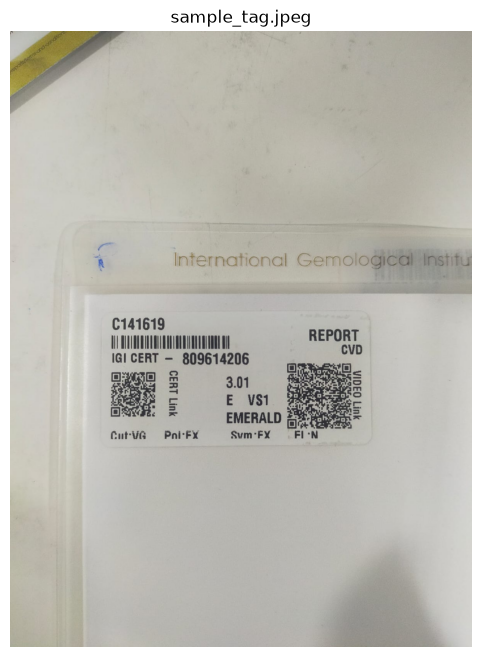

In [5]:
filename = "sample_tag.jpeg"  # <-- change this
image = cv2.imread(str(FIXTURES_DIR / filename), cv2.IMREAD_COLOR)

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(filename)
plt.show()

## Run PaddleOCR on it (with timing)

PaddleOCR 3.x's old `ocr.ocr(image, cls=True)` is deprecated in favor of `ocr.predict(image)`, which returns a list of one `OCRResult` dict per input image. `result[0]["rec_texts"]`, `["rec_scores"]`, and `["rec_polys"]` are parallel lists (text, confidence, and quadrilateral box) per detected text region -- similar in shape to EasyOCR's per-box output, unlike Tesseract's single text block.

In [6]:
t0 = time.time()
result = ocr.predict(image)
print(f"{time.time() - t0:.1f}s")

res = result[0]
detections = list(zip(res["rec_polys"], res["rec_texts"], res["rec_scores"]))
for box, text, conf in detections:
    print(f"{conf:.2f}  {text!r}")

6.5s
0.98  'International Gemological Instifu'
1.00  'C141619'
1.00  'REPORT'
0.98  'CVD'
0.93  'IGI CERT -'
1.00  '809614206'
1.00  'CERT Link'
1.00  '3.01'
0.89  'E VS1'
1.00  'EMERALD'
0.78  'Cut·vG'
0.81  'Pnl·FX'
0.83  'Svm·FX'
0.97  'FI·N'


## Reconstruct text lines from the detected boxes

Same approach as the EasyOCR notebook: boxes that sit on roughly the same row get grouped into one line (left-to-right), so the existing line-based `parsing.parse_fields` can be used. `y_tolerance` controls how close two boxes' vertical centers need to be to count as "the same row" -- tune it if lines are merging wrong or splitting wrong for a given photo.

In [7]:
def group_into_lines(detections, y_tolerance=15):
    items = []
    for box, text, conf in detections:
        ys = [p[1] for p in box]
        xs = [p[0] for p in box]
        items.append((sum(ys) / len(ys), min(xs), text))
    items.sort(key=lambda t: t[0])

    lines, current_line, current_y = [], [], None
    for y, x, text in items:
        if current_y is None or abs(y - current_y) <= y_tolerance:
            current_line.append((x, text))
            current_y = y if current_y is None else (current_y + y) / 2
        else:
            lines.append(" ".join(t for _, t in sorted(current_line)))
            current_line, current_y = [(x, text)], y
    if current_line:
        lines.append(" ".join(t for _, t in sorted(current_line)))
    return "\n".join(lines)


raw_text = group_into_lines(detections)
print(raw_text)

International Gemological Instifu
C141619
REPORT
CVD
IGI CERT - 809614206
3.01
CERT Link
E VS1
EMERALD
Cut·vG Pnl·FX Svm·FX FI·N


## Parse it with the existing field parser

In [8]:
fields = parse_fields(raw_text)
fields

{'igi_report_no': '809614206',
 'report_type': 'CVD',
 'shape': 'EMERALD',
 'carat': '3.01',
 'color': 'E',
 'clarity': 'VS1'}

## Score PaddleOCR across all 6 real photos

For each field, count correct / wrong / missing against the known ground truth. Re-run after changing `group_into_lines` (e.g. its `y_tolerance`) or after editing `parsing.py` to see the effect immediately.

In [9]:
def paddleocr_raw_text(img):
    res = ocr.predict(img)[0]
    detections = list(zip(res["rec_polys"], res["rec_texts"], res["rec_scores"]))
    return group_into_lines(detections)


def score(label, get_raw_text_fn):
    correct = wrong = missing = 0
    total_time = 0.0
    rows = []
    for fname, igi, *expected in CASES:
        img = cv2.imread(str(FIXTURES_DIR / fname), cv2.IMREAD_COLOR)
        t0 = time.time()
        text = get_raw_text_fn(img)
        elapsed = time.time() - t0
        total_time += elapsed
        parsed = parse_fields(text)
        for field, exp in zip(FIELDS, expected):
            actual = parsed.get(field)
            if actual is None:
                missing += 1
            elif actual == exp:
                correct += 1
            else:
                wrong += 1
        rows.append((fname, elapsed, parsed))
    total = len(CASES) * len(FIELDS)
    print(f"{label}: {correct}/{total} correct, {wrong} wrong, {missing} missing | avg {total_time/len(CASES):.1f}s/image")
    return rows


paddleocr_rows = score("PaddleOCR", paddleocr_raw_text)

PaddleOCR: 27/30 correct, 0 wrong, 3 missing | avg 5.8s/image


## Per-photo detail

In [10]:
for fname, elapsed, parsed in paddleocr_rows:
    print(f"=== {fname} ({elapsed:.1f}s) ===")
    print(parsed)
    print()

=== sample_tag.jpeg (6.2s) ===
{'igi_report_no': '809614206', 'report_type': 'CVD', 'shape': 'EMERALD', 'carat': '3.01', 'color': 'E', 'clarity': 'VS1'}

=== tag_e79422_marquise.jpeg (6.0s) ===
{'igi_report_no': '791655400', 'report_type': 'CVD', 'shape': 'MARQUISE', 'carat': '2.04', 'color': 'D', 'clarity': 'VVS2'}

=== tag_c141640_heart.jpeg (5.3s) ===
{'igi_report_no': '817630270', 'report_type': 'CVD', 'shape': 'HEART', 'carat': '1.00', 'color': None, 'clarity': None}

=== tag_e84454_emerald.jpeg (6.3s) ===
{'igi_report_no': '804633671', 'report_type': 'CVD', 'shape': 'EMERALD', 'carat': '2.97', 'color': 'E', 'clarity': 'VVS1'}

=== tag_c141641_heart.jpeg (5.7s) ===
{'igi_report_no': '817634109', 'report_type': None, 'shape': 'HEART', 'carat': '1.00', 'color': 'F', 'clarity': 'VS1'}

=== tag_e86943_oval.jpeg (5.5s) ===
{'igi_report_no': '809609517', 'report_type': 'CVD', 'shape': 'OVAL', 'carat': '1.00', 'color': 'D', 'clarity': 'VVS1'}



## Try your own photo

Drop an image anywhere under the project and point this at it -- e.g. a fresh crop you want to test.

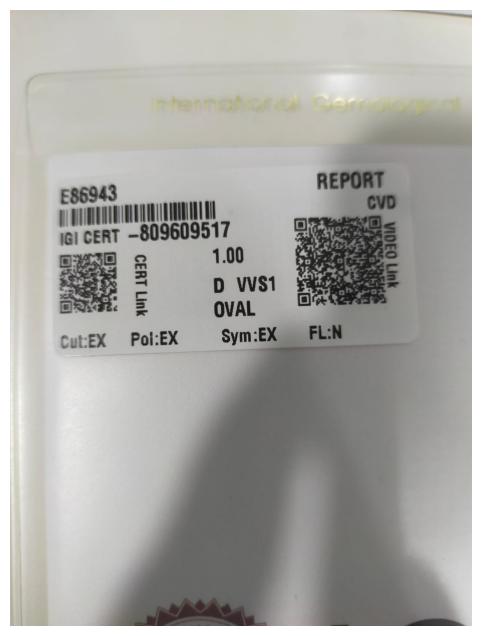

PaddleOCR: 7.6s
REPORT
E86943
CVD
MDNNN
IGI CERT -809609517
1.00
CERT Link D VVS1
OVAL
Cut:EX Pol:EX Sym:EX FL:N

Parsed: {'igi_report_no': '809609517', 'report_type': 'CVD', 'shape': 'OVAL', 'carat': '1.00', 'color': 'D', 'clarity': 'VVS1'}


In [12]:
my_photo_path = "tests/fixtures/tag_e86943_oval.jpeg"  # <-- change this

img = cv2.imread(my_photo_path, cv2.IMREAD_COLOR)
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

t0 = time.time()
text = paddleocr_raw_text(img)
print(f"PaddleOCR: {time.time() - t0:.1f}s")
print(text)
print()
print("Parsed:", parse_fields(text))